# Build a supervised model for predicting Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc with a defined applicability domain. It should be able to predict logKoc from a SMILES input and tell the user whether the new molecules fall into its AD. 

#### Tasks:
1) Load the training data
2) Build a supervised model of your choice (e.g., MACCS keys x Random Forest, but feel free to go for something more fancy) on 80% of the training data
3) Use an AD metric of your choice
4) Evaluate model on a 20% test set, and compare the prediction error with your AD metric
5) Predict the Koc and AD for 3 new substances.

In [1]:
# import
import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem.Descriptors import CalcMolDescriptors


#### 1. Load training data and split into train/test 80/20

In [2]:
# Loading the data from an sdf file
supplier = Chem.SDMolSupplier("../KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC']}
    }
    for m in supplier if m is not None
])

In [ ]:
# use RDKit descriptors
def RDKit_desc_from_smiles(smiles_list):
    descs = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        desc = CalcMolDescriptors(mol)≥≥
        descs.append(desc)
    return pd.DataFrame(descs)


df['LogKOC'] = pd.to_numeric(df['LogKOC'])
smiles = df['SMILES'].values # Structures (SMILES)
y = df['LogKOC'].values # Target variable

X = RDKit_desc_from_smiles(smiles) # Calculate molecular descriptors

In [4]:
# Verify for how many compounds features could be calculated
print(f'Input feature calculation: {len(smiles)} SMILES\n' )
# Drop features that could not be calculated for all compounds
X.dropna(axis="columns", how="any", inplace=True)
print("Number of features for modelling:", len(X.columns))

Input feature calculation: 728 SMILES

Number of features for modelling: 205


In [5]:
# split data into training and test
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

In [12]:
X_train

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
433,11.221090,11.221090,0.539628,-0.594707,0.783331,11.266667,223.659,213.579,223.040006,78,...,0,0,0,1,0,0,0,0,0,0
136,8.787315,8.787315,0.133488,0.133488,0.567108,9.125000,128.558,123.518,128.002892,42,...,0,0,0,0,0,0,0,0,0,0
350,5.767942,5.767942,0.817390,0.817390,0.428359,10.933333,193.249,182.161,193.089149,72,...,0,0,0,0,0,0,0,0,0,0
6,11.020471,11.020471,0.027351,-0.027351,0.673943,11.823529,223.275,210.171,223.099714,84,...,0,0,0,0,0,0,0,0,0,0
318,11.564078,11.564078,0.529031,0.529031,0.412358,11.333333,198.225,188.145,198.079313,74,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,10.534636,10.534636,0.102840,-0.779012,0.321157,10.357143,295.336,295.336,292.837167,76,...,0,0,0,0,0,0,0,0,0,0
106,1.560185,1.560185,1.155093,1.155093,0.481193,40.800000,138.254,120.110,138.140851,58,...,0,0,0,0,0,0,0,0,0,0
270,5.774681,5.774681,0.191019,0.191019,0.828699,10.866667,229.715,213.587,229.109423,84,...,0,0,0,0,0,0,0,0,0,0
435,10.348035,10.348035,0.565972,-0.590494,0.663987,9.181818,170.599,163.543,170.024691,58,...,0,0,0,0,0,0,0,0,0,1


#### 2. Build a supervised model of your choice

In [6]:
# standardize features
scaler = StandardScaler()
X_train_standard = scaler.fit_transform(X_train)
X_test_standard = scaler.fit_transform(X_test)

# train model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train_standard, y_train)
# predict logP for test set
y_pred = model.predict(X_test_standard)

Test R²: 0.7560700426219771
Test RMSE: 0.5867297033518277


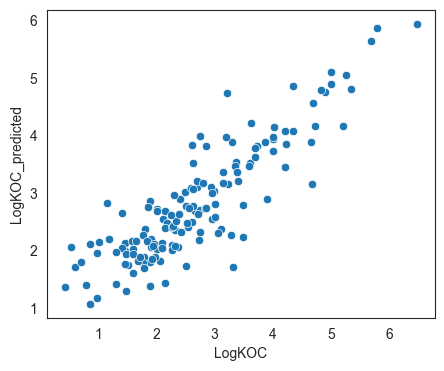

In [7]:
# Check performance
print('Test R²:', r2_score(y_test, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred))

df_test = pd.DataFrame({'LogKOC': y_test,
                        'LogKOC_predicted': y_pred,
                        'preferred_name': df['preferred_name'][indices_test],
                        'Error': np.abs(y_test - y_pred)
                        })
plt.figure(figsize=(5, 4))
sns.set_style('white')
sns.scatterplot(df_test, x='LogKOC', y='LogKOC_predicted')
plt.show()


#### 3. Choose an AD metric and define an AD threshold

In [8]:
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X_train_standard)

# esol test data
dist_esol, _ = nbrs.kneighbors(X_test_standard)
knn_dist_esol = dist_esol.mean(axis=1)
df_test['kNN_Distance'] = knn_dist_esol

#### 4) Evaluate model (R2, RMSE) on test set and compare the prediction error with your AD metric

Average of average distances: 
ESOL test: 8.033781467577247 



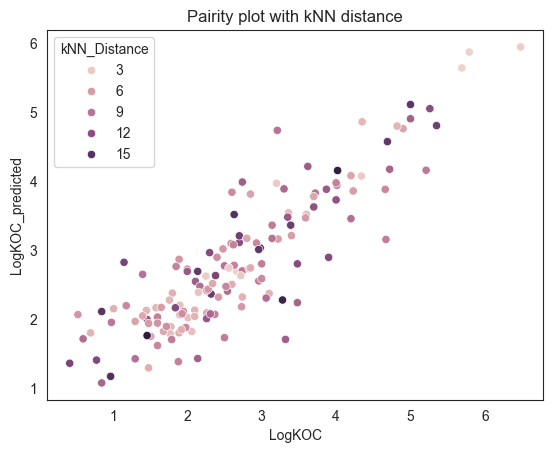

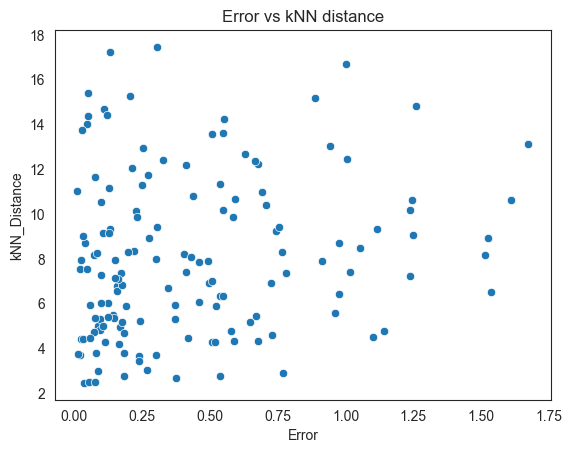

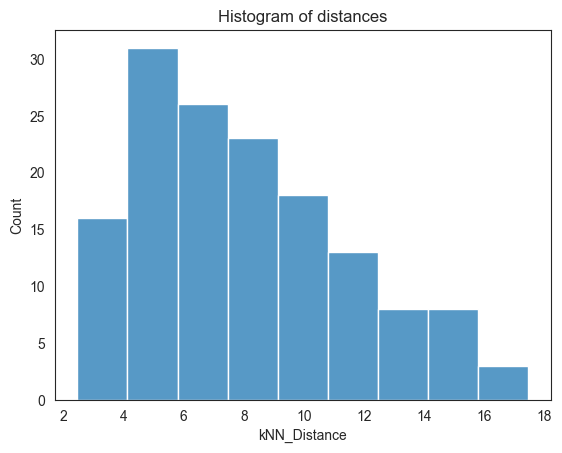

In [9]:
print(f'Average of average distances: \n'
      f'ESOL test: {knn_dist_esol.mean()} \n')

sns.scatterplot(df_test, x='LogKOC', y='LogKOC_predicted', hue='kNN_Distance')
plt.title('Pairity plot with kNN distance')
plt.show()
sns.scatterplot(df_test, x='Error', y='kNN_Distance')
plt.title('Error vs kNN distance')
plt.show()
sns.histplot(df_test, x='kNN_Distance')
plt.title('Histogram of distances')
plt.show()

#### 5) Predict the Koc and AD for 3 new substances. 

In [10]:
smiles_ext = {'PFOA': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O', 
          'Bisphenol A': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
          'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'} # or choose your own! 
df_ext = pd.DataFrame()
df_ext['Name'] = smiles_ext.keys()
df_ext['SMILES'] = smiles_ext.values()

In [11]:
# external test data
X_ext_all = RDKit_desc_from_smiles(df_ext['SMILES']) 
X_ext = X_ext_all[X.columns]
X_ext_standard = scaler.transform(X_ext)
y_ext_pred = model.predict(X_ext_standard)
dist_ext, neighbors_ext = nbrs.kneighbors(X_ext_standard)
knn_dist_ext = dist_ext.mean(axis=1)
df_ext['kNN_Distance'] = knn_dist_ext
df_ext['LogKOC'] = y_ext_pred
df_ext['within_AD'] = (knn_dist_ext < 16)
print(df_ext)

          Name                                             SMILES  \
0         PFOA  C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F...   
1  Bisphenol A                CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O   
2     Caffeine                       CN1C=NC2=C1C(=O)N(C(=O)N2C)C   

   kNN_Distance    LogKOC  within_AD  
0     64.499068  2.969733      False  
1     11.068313  3.679280       True  
2     17.224623  2.539736      False  


### Questions:
- Which AD metric did you choose, and why?
- How well does your model perform? Can you trust your AD metric?
- Are the new substances within the AD? Can you trust the Koc predictions? 

Notes: 
- low Koc -> substance is highly mobile in soil. 
- High logKoc (>4.5) -> high sorption to organic carbon
- Environmental (predicted) properties: Check out https://comptox.epa.gov/dashboard/